# Pentadic Tone-Space: Wilson's Eikosany and Hexadic Diamond from A4 Coxeter Theory

Erv Wilson's pentadic constructions -- the 31-point **Hexadic Diamond** and 20-point **Eikosany** built from the 6-set $\{1, 3, 5, 7, 9, 11\}$ -- are derived here from the A4 root system. **Two distinct readings of the same Generating Hexad pentagon** produce the two constructions: *chord-as-root* yields the Diamond (Section A); *chord-as-dyad* yields the Eikosany (Section B). The organising principle throughout is Pascal's Triangle.

Wilson's source figures appear in `dal.pdf`: Figure 1, Pascal's Triangle; Figure 13, Eikosany with Generating Hexad; Figure 14, Hexadic Diamond with Major / Minor Hexads.

## Pascal's Triangle

Wilson opens *D'Alessandro, like a Hurricane* with Pascal's Triangle. The 6-set $\{1, 3, 5, 7, 9, 11\}$ admits

$$ \binom{6}{3} \;=\; 20 $$

combinations of three elements -- these are the Eikosany pitches. Pascal's recursion

$$ \binom{6}{3} \;=\; \binom{5}{2} + \binom{5}{3} \;=\; 10 + 10 $$

decomposes those 20 into two halves: 10 triples *containing* 1 (which reduce to dyad-products $1 \cdot p_i \cdot p_j$) and 10 *not containing* 1 (triad-products $p_i \cdot p_j \cdot p_k$).

This is the bridge to **Pascal Row 5** $\;=\; (1, 5, 10, 10, 5, 1)$. The recursion's LHS counts subsets of an *explicit*-unity 6-set; its RHS counts subsets of an *implicit*-unity 5-set $\{3, 5, 7, 9, 11\}$. Adopting Coxeter theory on $A_4$ -- rank 4, ambient dimension 5 -- maps the five odd-prime generators to basis vectors $\varepsilon_1, \dots, \varepsilon_5$, and lifts unity to the origin (implicit, never one of the five generators). Pascal Row 5 then aligns with the $W(A_4)$-orbit sizes on the fundamental-weight lattice:

| Row 5 entry | $W(A_4)$ orbit | Form | Musical role |
|---|---|---|---|
| 1 | (origin) | $0$ | unison -- implicit unity |
| 5 | $W \cdot \Lambda_1$ | $+\varepsilon_i$ | otonals $\{3, 5, 7, 9, 11\}$ |
| 10 | $W \cdot \Lambda_2$ | $\varepsilon_i + \varepsilon_j$ | Eikosany "with 1" |
| 10 | $W \cdot \Lambda_3$ | $\varepsilon_i + \varepsilon_j + \varepsilon_k$ | Eikosany "no 1" |
| 5 | $W \cdot \Lambda_4 \equiv -\Lambda_1 \pmod{\mathbf{1}}$ | $-\varepsilon_i$ | utonals $\{1/3, 1/5, \dots\}$ |
| 1 | (complement) | $\mathbf{1} = (1,1,1,1,1)$ | the octave -- implicit endpoint |

The first and last Row-5 entries are **implicit endpoints** -- the origin (unison) and the octave -- bracketing the audible structure without themselves appearing as scale notes.

The notebook unfolds in two parallel sections, each drawing different orbits from this table:

- **Section A -- Hexadic Diamond** uses $\Lambda_1$ (signed) for the Major / Minor Hexad vertices and the $A_4$ root system $\Phi$ for the chord vectors. Diamond $= \{0\} \sqcup (W{\cdot}\Lambda_1) \sqcup -(W{\cdot}\Lambda_1) \sqcup \Phi$, with sizes $1 + 5 + 5 + 20 = 31$.

- **Section B -- Eikosany** uses $\Lambda_1$ for the Generating Hexad's vertices, $W{\cdot}\Lambda_2$ to index its 10 chords (pairs), and $W{\cdot}\Lambda_3$ to index its 10 triangles (triples). Eikosany $= (W{\cdot}\Lambda_2) \sqcup (W{\cdot}\Lambda_3)$, with size $10 + 10 = 20$.

The Generating Hexad pentagon **looks identical** in both sections -- Wilson uses the same pentagonal drawing for both Figure 13 and Figure 14. What differs is the *legend*: chord labels in Section A are root vectors $\varepsilon_i - \varepsilon_j$; in Section B they are dyad ratios $p_i : p_j$. Same picture, two arithmetic operations on the same indexed pairs.

In [1]:
import sys
sys.path.insert(0, '../src')

import itertools
import numpy as np
import matplotlib.pyplot as plt
from sympy import Rational

from coxeter_a4 import build_a4_system, build_eigenspaces, eigenvec_to_proj

In [2]:
R, ambient, W, s, cox, P = build_a4_system()
K, zeta, w_par, w_perp = build_eigenspaces(P)
proj = eigenvec_to_proj(w_par, K)

P_np = np.array(P, dtype=int)
eps = [ambient.basis()[i] for i in ambient.basis().keys()]
primes = [3, 5, 7, 9, 11]   # the five odd-prime-equivalent generators

print('A4 Coxeter element c = s1 s2 s3 s4  (cyclic permutation epsilon_i -> epsilon_{i+1}):')
print(P_np)
print()
print('2D projection pi : R^5 -> E_parallel  (rotation by 2pi/5 per Coxeter step):')
print(np.round(proj, 4))

A4 Coxeter element c = s1 s2 s3 s4  (cyclic permutation epsilon_i -> epsilon_{i+1}):
[[0 0 0 0 1]
 [1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]]

2D projection pi : R^5 -> E_parallel  (rotation by 2pi/5 per Coxeter step):
[[ 0.6325  0.1954 -0.5117 -0.5117  0.1954]
 [-0.      0.6015  0.3717 -0.3717 -0.6015]]


## Pascal Row 5 $\leftrightarrow$ $W(A_4)$ fundamental-weight orbits

Build the four $W(A_4)$ orbits of the fundamental weights $\Lambda_1, \Lambda_2, \Lambda_3, \Lambda_4$ explicitly. Their sizes are Pascal Row 5 entries (excluding the two implicit endpoints).

In [3]:
Lambda = ambient.fundamental_weights()

def orbit_5D(k):
    """W(A4)-orbit of the k-th fundamental weight as integer 5D vectors."""
    return np.array([np.array(v.to_vector(), dtype=int)
                     for v in Lambda[k].orbit()])

L1 = orbit_5D(1)
L2 = orbit_5D(2)
L3 = orbit_5D(3)
L4 = orbit_5D(4)

print('Pascal Row 5  <->  W(A4) fundamental-weight orbit sizes:')
print(f'  C(5,1) = {len(L1):2d}    W.Lambda_1   otonals   (+epsilon_i)')
print(f'  C(5,2) = {len(L2):2d}    W.Lambda_2   dyads     (epsilon_i + epsilon_j)        - Eikosany "with 1"')
print(f'  C(5,3) = {len(L3):2d}    W.Lambda_3   triads    (epsilon_i + epsilon_j + epsilon_k) - Eikosany "no 1"')
print(f'  C(5,4) = {len(L4):2d}    W.Lambda_4   utonals   (= -epsilon_i mod ones-vector)')
print()
print('Implicit endpoints: C(5,0) = 1 (origin / unison),  C(5,5) = 1 (ones-vector / octave)')

Pascal Row 5  <->  W(A4) fundamental-weight orbit sizes:
  C(5,1) =  5    W.Lambda_1   otonals   (+epsilon_i)
  C(5,2) = 10    W.Lambda_2   dyads     (epsilon_i + epsilon_j)        - Eikosany "with 1"
  C(5,3) = 10    W.Lambda_3   triads    (epsilon_i + epsilon_j + epsilon_k) - Eikosany "no 1"
  C(5,4) =  5    W.Lambda_4   utonals   (= -epsilon_i mod ones-vector)

Implicit endpoints: C(5,0) = 1 (origin / unison),  C(5,5) = 1 (ones-vector / octave)


In [4]:
# JI ratio (sympy Rational) for a 5D lattice vector under the mapping epsilon_i -> primes[i]
def ratio(v_5D):
    num = den = 1
    for p, e in zip(primes, v_5D):
        if   e > 0: num *= p ** int(e)
        elif e < 0: den *= p ** int(-e)
    return Rational(num, den)

def octave_reduce(r):
    while r > 2: r = r / 2
    while r < 1: r = r * 2
    return r

# Root-vector label for the chord-as-root reading (Section A): 'epsilon_i - epsilon_j'
def root_label(r5):
    i = int((r5 ==  1).argmax()) + 1
    j = int((r5 == -1).argmax()) + 1
    return f'e{i}-e{j}'

# Dyad-pair label for the chord-as-dyad reading (Section B): 'p_i : p_j'
def dyad_label(r5):
    i = int((r5 ==  1).argmax())
    j = int((r5 == -1).argmax())
    return f'{primes[i]}:{primes[j]}'

# Product label for Eikosany lattice points: '1.3.5' (Lambda_2) or '3.5.7' (Lambda_3)
def product_label(v_5D):
    factors = [str(p) for p, e in zip(primes, v_5D) for _ in range(int(e))]
    if int(sum(v_5D)) == 2:   # Lambda_2: prepend implicit unity
        factors = ['1'] + factors
    return '.'.join(factors)

## Section A -- The Hexadic Diamond via $A_4$ roots

The first reading of the Generating Hexad treats each of its 10 chords as a **root vector** $\alpha_{ij} = \varepsilon_i - \varepsilon_j$ -- an element of the $A_4$ root system $\Phi$. Two Hexads appear, mirroring each other:

- **Major Hexad**: 5 otonal vertices $+\varepsilon_i \in W \cdot \Lambda_1$ joined by 10 positive-root chord vectors $\Phi^+$.
- **Minor Hexad**: 5 utonal vertices $-\varepsilon_i \in -(W \cdot \Lambda_1)$ joined by 10 negative-root chord vectors $\Phi^-$.

The Diamond is then assembled by promoting each root chord-vector to an origin-anchored position point, and overlaying both pentagons plus the origin:

$$ \mathrm{Diamond} \;=\; \{0\} \;\sqcup\; (W{\cdot}\Lambda_1) \;\sqcup\; -(W{\cdot}\Lambda_1) \;\sqcup\; \Phi $$

with sizes $1 + 5 + 5 + 20 = 31$. The 20 roots are *position* points in the Diamond -- they sit at projected locations $\pi(\varepsilon_i - \varepsilon_j) = P_i - P_j$, intermediate to the otonal and utonal pentagons.

Wilson labels the otonal pentagon "MAJOR HEXAD" and the utonal pentagon "MINOR HEXAD" in his Figure 14.

In [5]:
# Otonal and utonal vertex sets (signed Lambda_1)
otonal_5D = L1
utonal_5D = -L1

# Positive and negative roots
pos_roots = np.array([np.array(r.to_vector(), dtype=int) for r in ambient.positive_roots()])
neg_roots = -pos_roots

# Anchor index: for each root, the position of -1 (positive root) or +1 (negative root)
# identifies the otonal/utonal endpoint the chord is anchored at.
pr_from = (pos_roots == -1).argmax(axis=1)
nr_from = (neg_roots ==  1).argmax(axis=1)

# 2D projections
pr_proj     = pos_roots  @ proj.T
nr_proj     = neg_roots  @ proj.T
otonal_proj = otonal_5D  @ proj.T
utonal_proj = utonal_5D  @ proj.T

# Root-vector legend labels (Section A reading)
pr_root_labels = [root_label(r) for r in pos_roots]
nr_root_labels = [root_label(r) for r in neg_roots]

In [6]:
def draw_hexad(ax, root_segs, anchors, anchor_idx, labels, vertex_color, title):
    """Render one hexad on `ax`: anchored chord segments, origin radii, and vertex markers.

    The K_5 chord between two vertices is drawn as the segment from the anchor vertex
    along the root segment to the second vertex. Five additional radii from the origin
    to each anchor complete the K_6 figure that Wilson draws.

    The 2D coordinates are rotated 90 degrees, (x, y) -> (-y, x), to match Wilson's
    orientation (otonal vertex 3 at the top).
    """
    for k, r in enumerate(root_segs):
        a = anchors[anchor_idx[k]]
        seg = np.vstack((a, a + r))
        ax.plot(-seg[:, 1], seg[:, 0], label=labels[k], linewidth=1.2)

    for v in anchors:
        ax.plot([0, -v[1]], [0, v[0]], color=vertex_color, linewidth=0.8, alpha=0.5)

    ax.scatter(-anchors[:, 1], anchors[:, 0], c=vertex_color, s=60, zorder=3)
    ax.scatter([0], [0], c='k', s=40, zorder=3)

    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend(bbox_to_anchor=(1.0, 1.0), fontsize=8)

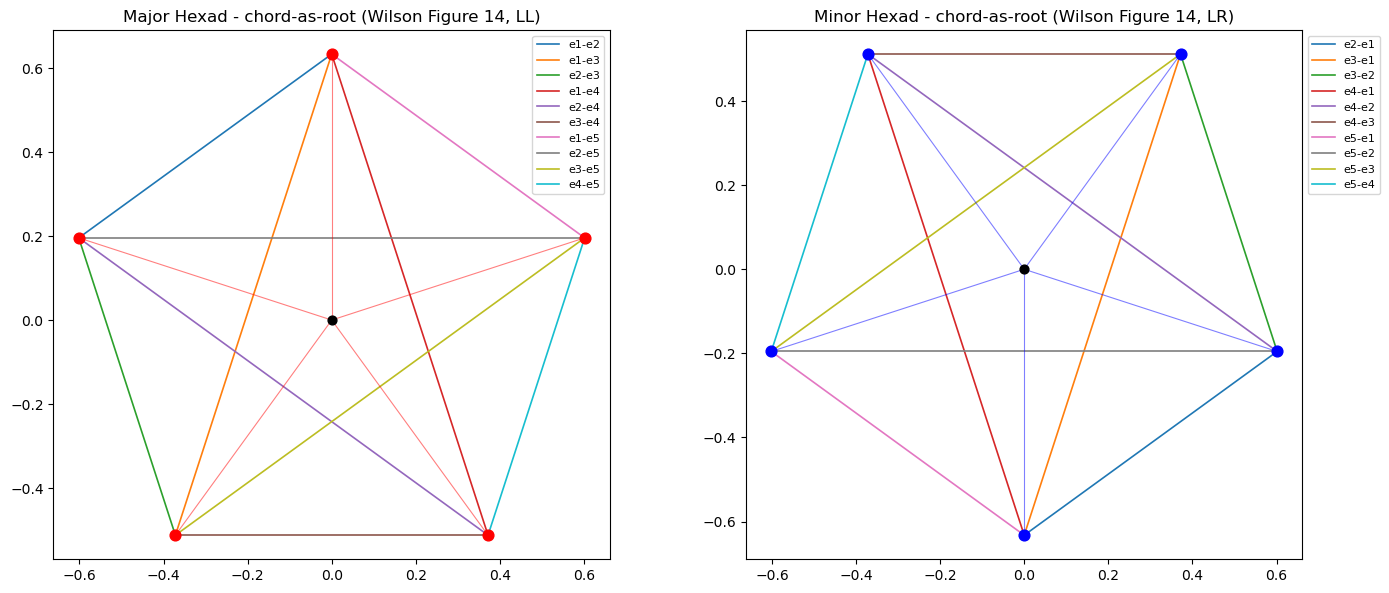

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

draw_hexad(axes[0], pr_proj, otonal_proj, pr_from, pr_root_labels,
           vertex_color='r', title='Major Hexad - chord-as-root (Wilson Figure 14, LL)')

draw_hexad(axes[1], nr_proj, utonal_proj, nr_from, nr_root_labels,
           vertex_color='b', title='Minor Hexad - chord-as-root (Wilson Figure 14, LR)')

plt.tight_layout()
plt.show()

### From Major/Minor Hexads to the Hexadic Diamond

Each chord of the two Hexads is a *root vector* $\pi(\varepsilon_i - \varepsilon_j) = P_i - P_j$ -- a translation, not yet a position. Promoting each root vector to an origin-anchored *position* point yields the 20 root-points of the Diamond, which sit between the otonal and utonal pentagons. Overlaying the origin (1), the 5 otonals $+\varepsilon_i$, the 5 utonals $-\varepsilon_i$, and the 20 roots produces the full 31-point Hexadic Diamond (Wilson's Figure 14, main).

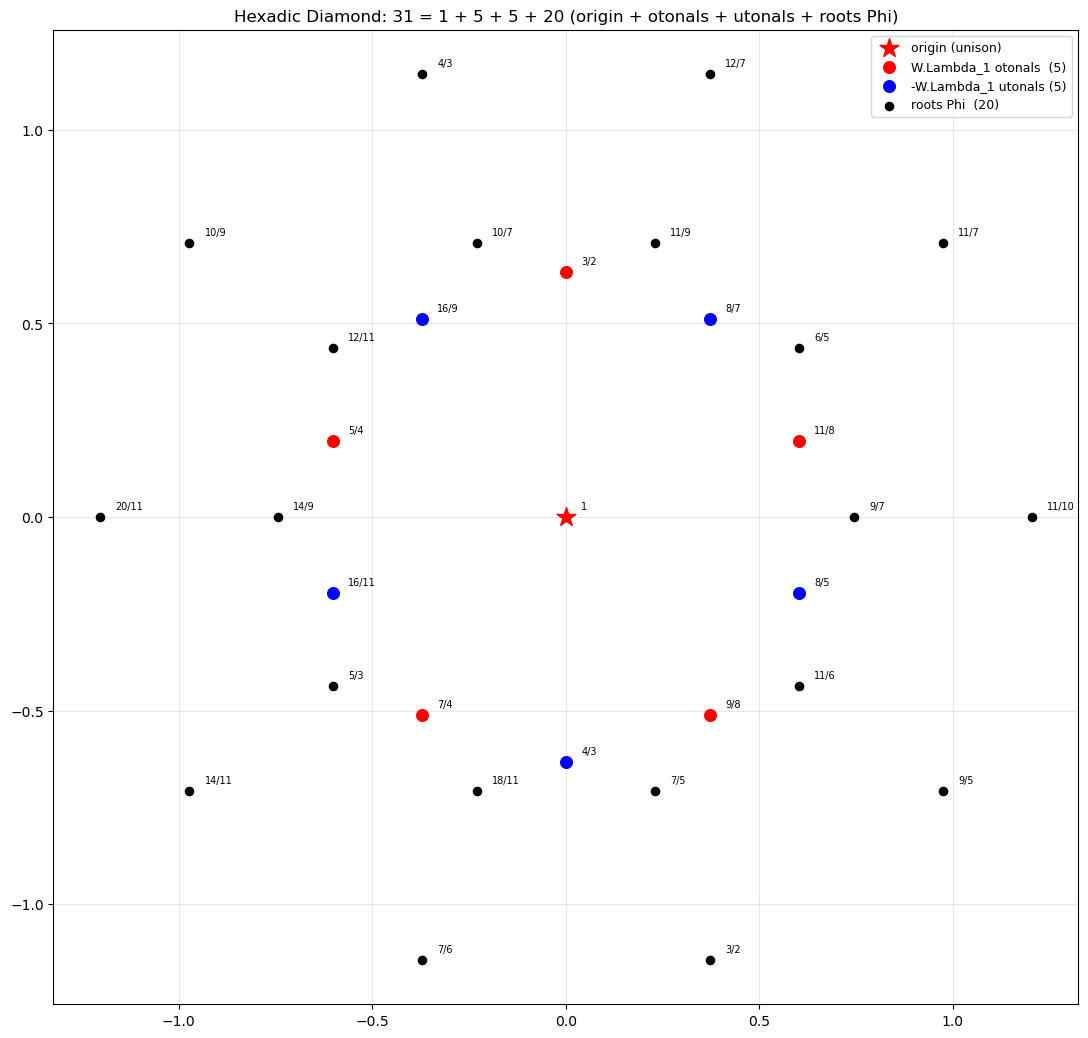

In [8]:
# Assemble the 31-point Diamond
roots_5D = np.array([np.array(r.to_vector(), dtype=int)
                     for r in ambient.roots()])
diamond_5D = np.vstack([np.zeros((1, 5), dtype=int),
                        otonal_5D, utonal_5D, roots_5D])

# Diamond filter: at most one +1 and at most one -1 per row (Wilson's defining property)
assert all((np.sum(pt < 0) < 2) and (np.sum(pt > 0) < 2) for pt in diamond_5D)
assert len(diamond_5D) == 31

xy_d = diamond_5D @ proj.T
x_d  = -xy_d[:, 1]
y_d  =  xy_d[:, 0]

fig, ax = plt.subplots(figsize=(11, 11))

# Color-code by piece
ax.scatter([0], [0], color='r', s=200, marker='*', zorder=5,
           label='origin (unison)')
ax.scatter(x_d[1:6],  y_d[1:6],  color='r', s=70, zorder=4,
           label=f'W.Lambda_1 otonals  ({len(L1)})')
ax.scatter(x_d[6:11], y_d[6:11], color='b', s=70, zorder=4,
           label=f'-W.Lambda_1 utonals ({len(L1)})')
ax.scatter(x_d[11:],  y_d[11:],  color='k', s=35, zorder=3,
           label=f'roots Phi  ({len(roots_5D)})')

# Octave-reduced JI ratio annotations
for k, v in enumerate(diamond_5D):
    r = octave_reduce(ratio(v))
    ax.annotate(str(r), xy=(x_d[k]+0.04, y_d[k]+0.02), fontsize=7, zorder=6)

ax.set_aspect('equal')
ax.set_title(f'Hexadic Diamond: {len(diamond_5D)} = 1 + 5 + 5 + 20 (origin + otonals + utonals + roots Phi)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Section B -- The Eikosany via fundamental-weight orbits

The second reading of the same Generating Hexad reinterprets its geometric content through **fundamental-weight orbits** rather than roots. The pentagonal drawing is unchanged; the *arithmetic operation* on the index pairs flips from difference to sum:

| Hexad feature | Indexing orbit | Construction | Pascal Row 5 entry |
|---|---|---|---|
| 5 vertices | $W \cdot \Lambda_1$ | $+\varepsilon_i$ | $\binom{5}{1} = 5$ |
| 10 chords (pairs $\{i,j\}$) | $W \cdot \Lambda_2$ | $\varepsilon_i + \varepsilon_j$ | $\binom{5}{2} = 10$ |
| 10 triangles (triples $\{i,j,k\}$) | $W \cdot \Lambda_3$ | $\varepsilon_i + \varepsilon_j + \varepsilon_k$ | $\binom{5}{3} = 10$ |

The chord between vertices $\varepsilon_i$ and $\varepsilon_j$ no longer represents the *difference* $\varepsilon_i - \varepsilon_j$ (a root); it now indexes the *sum* $\varepsilon_i + \varepsilon_j$ (a $\Lambda_2$ dyad). Wilson labels this pentagon "GENERATING HEXAD" in his Figure 13 -- distinct from the Figure 14 "MAJOR HEXAD" name, even though the drawing is identical.

Note the asymmetry with Section A: the Eikosany lives entirely in the positive cone (all orbit elements have non-negative coordinates), so **only the otonal Generating Hexad is needed** -- there is no Minor analogue here. This is the "implicit unity" pattern at work: every Eikosany pitch is reached by *positive* combination of the five generators $\{3, 5, 7, 9, 11\}$.

W.Lambda_2 orbit  ->  Generating Hexad chord pairs on the W.Lambda_1 pentagon:
  (10 dyads from orbit_5D(2), built via Lambda[2].orbit() in SageMath)

  (1, 1, 0, 0, 0)  =  e1 + e2  ->  chord (3, 5)   dyad pitch = 1.3.5 = 15
  (1, 0, 1, 0, 0)  =  e1 + e3  ->  chord (3, 7)   dyad pitch = 1.3.7 = 21
  (0, 1, 1, 0, 0)  =  e2 + e3  ->  chord (5, 7)   dyad pitch = 1.5.7 = 35
  (1, 0, 0, 1, 0)  =  e1 + e4  ->  chord (3, 9)   dyad pitch = 1.3.9 = 27
  (0, 1, 0, 1, 0)  =  e2 + e4  ->  chord (5, 9)   dyad pitch = 1.5.9 = 45
  (1, 0, 0, 0, 1)  =  e1 + e5  ->  chord (3, 11)   dyad pitch = 1.3.11 = 33
  (0, 0, 1, 1, 0)  =  e3 + e4  ->  chord (7, 9)   dyad pitch = 1.7.9 = 63
  (0, 1, 0, 0, 1)  =  e2 + e5  ->  chord (5, 11)   dyad pitch = 1.5.11 = 55
  (0, 0, 1, 0, 1)  =  e3 + e5  ->  chord (7, 11)   dyad pitch = 1.7.11 = 77
  (0, 0, 0, 1, 1)  =  e4 + e5  ->  chord (9, 11)   dyad pitch = 1.9.11 = 99


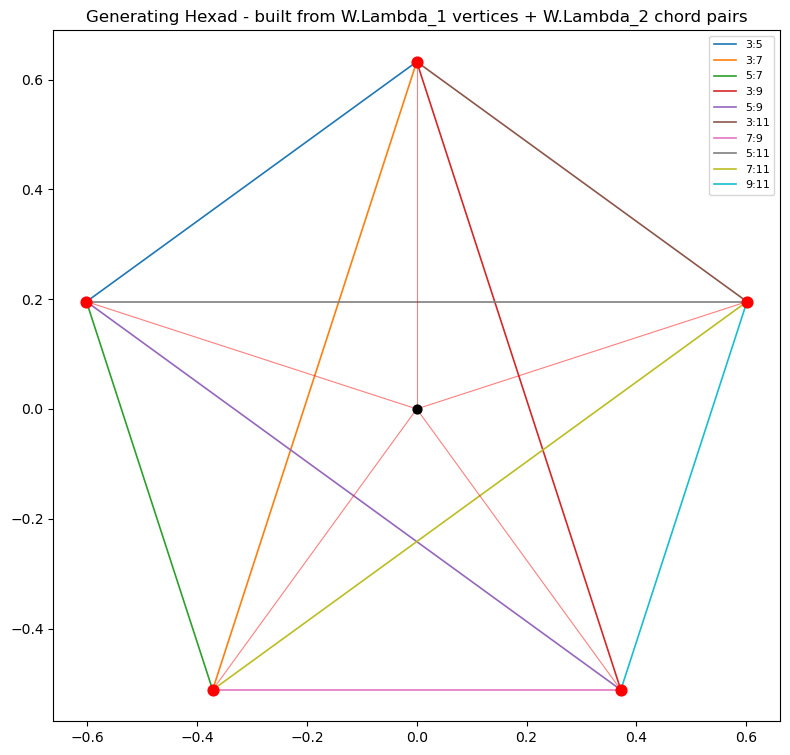

In [9]:
# Build the Generating Hexad explicitly from W(A4) orbits:
#   W.Lambda_1 (5 vertices)  ->  pentagon corners
#   W.Lambda_2 (10 dyads)    ->  chord pairs
#
# Each Lambda_2 element  v = epsilon_i + epsilon_j  has +1 at exactly two coordinate
# positions; those positions identify the two L1 vertices the chord connects.

def dyad_to_pair(v_5D):
    """Return the ordered pair (i, j), i < j, of L1 indices a Lambda_2 dyad spans."""
    idx = np.where(v_5D == 1)[0]
    return int(idx[0]), int(idx[1])

l2_pairs = [dyad_to_pair(v) for v in L2]

print('W.Lambda_2 orbit  ->  Generating Hexad chord pairs on the W.Lambda_1 pentagon:')
print(f'  (10 dyads from orbit_5D(2), built via Lambda[2].orbit() in SageMath)\n')
for v, (i, j) in zip(L2, l2_pairs):
    coords = tuple(int(x) for x in v)
    print(f'  {coords}  =  e{i+1} + e{j+1}  ->  chord ({primes[i]}, {primes[j]})'
          f'   dyad pitch = 1.{primes[i]}.{primes[j]} = {primes[i]*primes[j]}')

# Vertex positions (2D) from L1; chord vectors and anchors derived from l2_pairs
otonal_xy     = L1 @ proj.T
gh_chord_vecs = np.array([otonal_xy[j] - otonal_xy[i] for (i, j) in l2_pairs])
gh_anchor_idx = np.array([i for (i, j) in l2_pairs])
gh_labels     = [f'{primes[i]}:{primes[j]}' for (i, j) in l2_pairs]

fig, ax = plt.subplots(figsize=(8, 8))
draw_hexad(ax, gh_chord_vecs, otonal_xy, gh_anchor_idx, gh_labels,
           vertex_color='r',
           title='Generating Hexad - built from W.Lambda_1 vertices + W.Lambda_2 chord pairs')
plt.tight_layout()
plt.show()

### Chord vectors as Eikosany translations

The 10 chord *vectors* of the Generating Hexad remain root projections, $\pi(\varepsilon_j - \varepsilon_i) = P_j - P_i$. Under the dyad reading they play a second geometric role: they are exactly the **translation generators** that move one Eikosany dyad-point to another. For any $k \notin \{i, j\}$,

$$ (\varepsilon_j + \varepsilon_k) \;-\; (\varepsilon_i + \varepsilon_k) \;=\; \varepsilon_j - \varepsilon_i, $$

so the Eikosany segment from dyad-point $P_i + P_k$ to $P_j + P_k$ has *the same vector and length* as the Hexad chord from $P_i$ to $P_j$. The analogous identity holds for triads, replacing one summand $\varepsilon_i$ by $\varepsilon_j$. Each Hexad chord therefore appears in the Eikosany as **six parallel, equal-length translates** -- three among $\Lambda_2$ dyad-points, three among $\Lambda_3$ triad-points -- distributed across the Eikosany figure rather than collected at the origin.

Geometrically, this means the **Eikosany can be reached from any one of its lattice points by stepping along Hexad chord vectors**. Starting from the seed dyad $\varepsilon_1 + \varepsilon_2$ at $P_1 + P_2$ (the parallelogram-rule sum of two Hexad radii), the remaining 9 dyads are reached by chord-vector translations; triads enter via the analogous parallelogram completion of three Hexad radii.

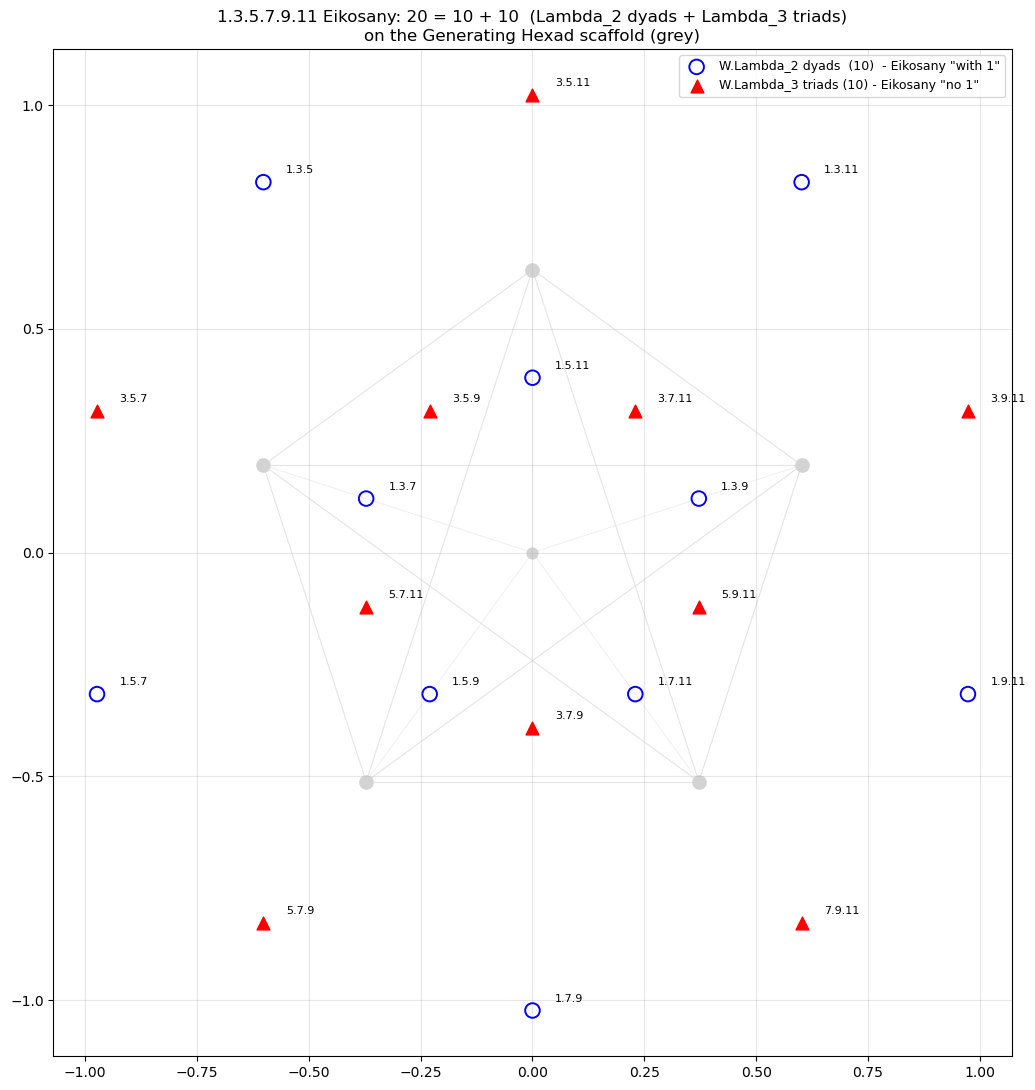

In [10]:
# Eikosany = W.Lambda_2  sqcup  W.Lambda_3
eikosany_5D = np.vstack([L2, L3])
assert len(eikosany_5D) == 20

xy_e = eikosany_5D @ proj.T
x_e  = -xy_e[:, 1]
y_e  =  xy_e[:, 0]

# Hexad scaffold (light grey) - context for where the Eikosany sits relative to the Generating Hexad
xy_h = otonal_5D @ proj.T
xh_, yh_ = -xy_h[:, 1], xy_h[:, 0]

fig, ax = plt.subplots(figsize=(11, 11))

# Scaffold: pentagon vertices + K_6 chords (lightgrey backdrop)
ax.scatter(xh_, yh_, color='lightgrey', s=90, zorder=1)
ax.scatter([0], [0], color='lightgrey', s=60, zorder=1)
for i, j in itertools.combinations(range(5), 2):
    ax.plot([xh_[i], xh_[j]], [yh_[i], yh_[j]],
            color='lightgrey', linewidth=0.8, alpha=0.6, zorder=0)
for k in range(5):
    ax.plot([0, xh_[k]], [0, yh_[k]],
            color='lightgrey', linewidth=0.6, alpha=0.4, zorder=0)

# Lambda_2 dyads (10) - open circles
n2 = len(L2)
ax.scatter(x_e[:n2], y_e[:n2],
           facecolors='none', edgecolors='blue', s=110, linewidths=1.4,
           label=f'W.Lambda_2 dyads  ({n2})  - Eikosany "with 1"', zorder=3)

# Lambda_3 triads (10) - filled triangles
ax.scatter(x_e[n2:], y_e[n2:], marker='^', color='red', s=85,
           label=f'W.Lambda_3 triads ({len(L3)}) - Eikosany "no 1"', zorder=3)

# Product-form annotations
for k, v in enumerate(eikosany_5D):
    ax.annotate(product_label(v), xy=(x_e[k]+0.05, y_e[k]+0.02),
                fontsize=8, zorder=4)

ax.set_aspect('equal')
ax.set_title(f'1.3.5.7.9.11 Eikosany: {len(eikosany_5D)} = 10 + 10  (Lambda_2 dyads + Lambda_3 triads)\n'
             f'on the Generating Hexad scaffold (grey)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Conclusion: Eikosany--Diamond overlay (forward reference)

The two 20-point structures developed above -- the Hexadic Diamond roots $\Phi$ (Section A) and the Eikosany weight-orbit union $W{\cdot}\Lambda_2 \sqcup W{\cdot}\Lambda_3$ (Section B) -- are **distinct point sets** sharing the same $A_4$ weight lattice scaffolding. They are related by **Galois conjugation** $\zeta_5 \leftrightarrow \zeta_5^2$ in the cyclotomic field $\mathbb{Q}(\zeta_5)$ that hosts the Coxeter projection.

A deeper structural fact connects them: a $C_5$ orbit of the Coxeter element $c = s_1 s_2 s_3 s_4$ acting on appropriately chosen $\Lambda_2$ and $\Lambda_3$ seeds generates **10 outer-ring divisors** whose 10 Eikosany translates **jointly cover all 31 Diamond points**. The count $10 = |D_5|$ is dihedral (the symmetry of the pentagon) rather than Pascal -- the spine ends here, and a different symmetry takes over.

For the full overlay construction -- variant enumeration, Coxeter-orbit seed selection, HEJI-form factorisation labels, and the per-variant coverage statistics -- see [`notebooks/eikosany_diamond_coxeter.ipynb`](eikosany_diamond_coxeter.ipynb). The treatment of the *inverse* Eikosany (Wilson's barred Generating Hexad in Figure 13, generating $-\Lambda_2 \sqcup -\Lambda_3$) also belongs to that follow-on notebook.